# Library Import

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import font_manager, rc
import platform

if platform.system() == 'Windows':
    font_path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# 데이터 내 한국어 포함으로 인하여 폰트 설정이 필요합니다.

# Data Preprocessing
* 본 데이터는 '소방청'에서 다운로드 받을 수 있으며, "지역별 10년 화재 통계 데이터"이다.

In [ ]:
df = pd.read_csv('../data/statistics/raw_data.csv', encoding='cp949')
df

# 전국 데이터가 모두 섞여있음.

,화재발생년원일,시도,시군구,화재유형,발화요인대분류,발화요인소분류,인명피해(명)소계,사망,부상,재산피해소계,장소대분류,장소중분류,장소소분류
0,2019-01-01 0:03,강원특별자치도,삼척시,기타(쓰레기 화재등),부주의,폭죽놀이,1,0,1,0,기타,야외,기타야외
1,2019-01-01 0:06,경기도,평택시,"건축,구조물",미상,미상,0,0,0,14900,주거,단독주택,단독주택
2,2019-01-01 0:40,서울특별시,성북구,"자동차,철도차량",미상,미상,0,0,0,3642,"자동차,철도차량",자동차,승용자동차
3,2019-01-01 0:52,경기도,이천시,기타(쓰레기 화재등),화학적 요인,자연발화,0,0,0,1848,기타,야외,야적장
4,2019-01-01 1:06,부산광역시,부산진구,"건축,구조물",전기적 요인,절연열화에 의한 단락,0,0,0,45,기타서비스,기타건축물,기타 건축물
...,...,...,...,...,...,...,...,...,...,...,...,...,...
523500,2015-12-31 22:39,서울특별시,강남구,"건축,구조물",미상,미상,0,0,0,59142,교육시설,"연구,학원",외국어학원
523501,2015-12-31 23:01,경상북도,청도군,"건축,구조물",전기적 요인,미확인단락,0,0,0,9784,"판매,업무시설",판매시설,전통시장
523502,2015-12-31 23:35,강원도,양구군,"건축,구조물",전기적 요인,접촉불량에 의한 단락,0,0,0,0,주거,단독주택,다가구주택
523503,2015-12-31 23:42,충청북도,청주시서원구,"건축,구조물",기타,기타,0,0,0,2336,산업시설,동식물시설,기타 동식물시설


In [ ]:
df.info()

# Insight: Null 값은 없으며, 화재발생년월일은 object 타입으로 되어 있어 연도별 분석을 위해 datetime 타입으로 변환 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523505 entries, 0 to 523504
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   화재발생년원일    523505 non-null  object
 1   시도         523505 non-null  object
 2   시군구        523505 non-null  object
 3   화재유형       523505 non-null  object
 4   발화요인대분류    523505 non-null  object
 5   발화요인소분류    523505 non-null  object
 6   인명피해(명)소계  523505 non-null  int64 
 7   사망         523505 non-null  int64 
 8   부상         523505 non-null  int64 
 9   재산피해소계     523505 non-null  int64 
 10  장소대분류      523505 non-null  object
 11  장소중분류      523505 non-null  object
 12  장소소분류      523505 non-null  object
dtypes: int64(4), object(9)
memory usage: 51.9+ MB


In [21]:
df['화재발생년원일'] = pd.to_datetime(df['화재발생년원일'], errors='coerce')
df['화재발생년원일'] = df['화재발생년원일'].dt.year.astype('Int64')
df.info()

# Transform '화재발생년원일' to dataetime format
# Transform '화재발생년원일' to year only

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523505 entries, 0 to 523504
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   화재발생년원일    523505 non-null  Int64 
 1   시도         523505 non-null  object
 2   시군구        523505 non-null  object
 3   화재유형       523505 non-null  object
 4   발화요인대분류    523505 non-null  object
 5   발화요인소분류    523505 non-null  object
 6   인명피해(명)소계  523505 non-null  int64 
 7   사망         523505 non-null  int64 
 8   부상         523505 non-null  int64 
 9   재산피해소계     523505 non-null  int64 
 10  장소대분류      523505 non-null  object
 11  장소중분류      523505 non-null  object
 12  장소소분류      523505 non-null  object
dtypes: Int64(1), int64(4), object(8)
memory usage: 52.4+ MB


# Visualization

## Top 5 Region by Total Fire Incidents

전국 평균 대비 화성시의 화재 발생 비율: 4.469308035714286


C:\Users\KYEONG HA\AppData\Local\Temp\ipykernel_15632\881390236.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.index, y=top5.values, palette="pastel")


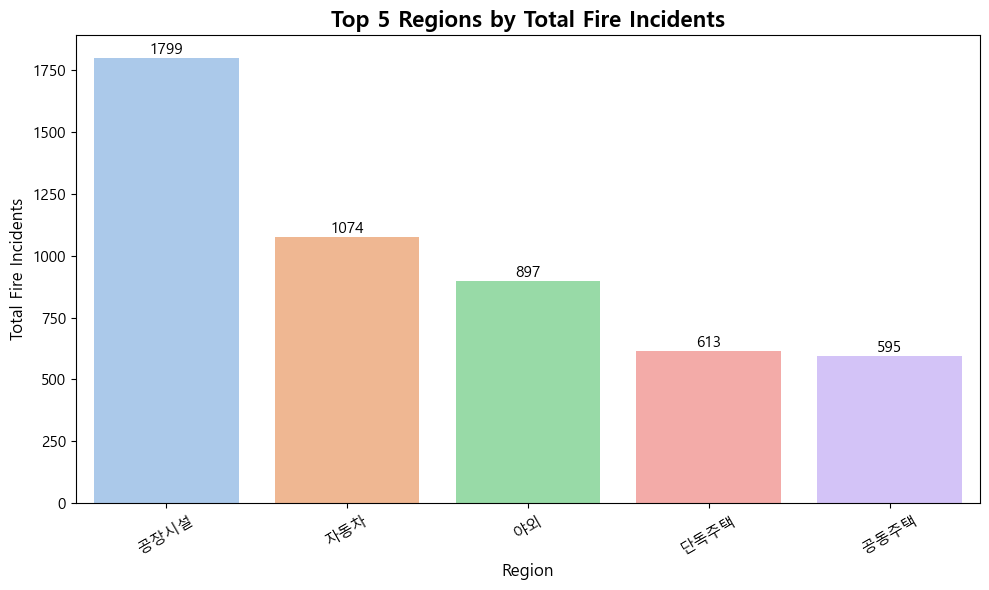

In [ ]:
df['지역'] = df['시도'] + ' ' + df['시군구']
df_hwaseong = df[df['지역'] == '경기도 화성시']
region_fire_incidents = df['지역'].value_counts()
region_average_fire_incidents_value = int(region_fire_incidents.values.mean())
hwaseong_fire_incidents_value = int(region_fire_incidents["경기도 화성시"])
region_top5 = region_fire_incidents.head(5)

print(f"전국 평균 대비 화성시의 화재 발생 비율: {hwaseong_fire_incidents_value / region_average_fire_incidents_value}")

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top5.index, y=top5.values, palette="pastel")

plt.title('Top 5 Regions by Total Fire Incidents', fontsize=16, weight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Fire Incidents', fontsize=12)
plt.xticks(rotation=30, ha = 'center', fontsize=11)
plt.yticks(fontsize=11)

for i, value in enumerate(top5.values):
    plt.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Insight: 화성시가 10년 화재 발생 통계 중 전국 1위를 차지하고 있다.
#        : 화성시는 전국 지역별 화재 평균 대비 약 4.7배의 화재가 발생하고 있다.

## Top 5 Ignition Locations in Hwaseong-si

C:\Users\KYEONG HA\AppData\Local\Temp\ipykernel_15632\2889388537.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.index, y=location_in_hwaseong_top5.values, palette="pastel")


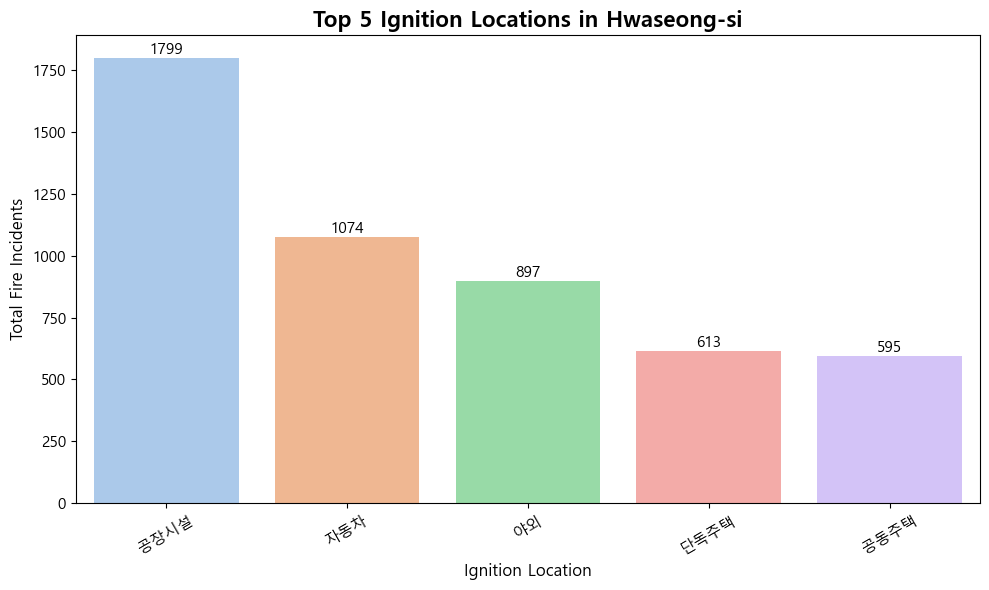

In [37]:
location_in_hwaseong_top5 = df_hwaseong['장소중분류'].value_counts().head(5)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top5.index, y=location_in_hwaseong_top5.values, palette="pastel")

plt.title('Top 5 Ignition Locations in Hwaseong-si', fontsize=16, weight='bold')
plt.xlabel('Ignition Location', fontsize=12)
plt.ylabel('Total Fire Incidents', fontsize=12)
plt.xticks(rotation=30, ha='center', fontsize=11)
plt.yticks(fontsize=11)

for i, value in enumerate(location_in_hwaseong_top5.values):
    plt.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Insight: 화성시 내부에는 '공장시설'에서 가장 많은 화재가 발생하였다.

# 추가 분석) 타지역 대비 화성시 공장 보유 수 현황

In [65]:
def replace_(x):
    return x.replace(",", "")

In [66]:
df = pd.read_csv("../data/statistics/전국_공장_등록현황.csv")
df

,시도명,시군구명,합계
0,서울특별시,종로구,173
1,서울특별시,중구,"1,133"
2,서울특별시,용산구,58
3,서울특별시,성동구,870
4,서울특별시,광진구,147
...,...,...,...
261,전북특별자치도,임실군,118
262,전북특별자치도,순창군,141
263,전북특별자치도,고창군,194
264,전북특별자치도,부안군,210


In [ ]:
df['합계'] = df['합계'].apply(replace_)
df['합계'] = df['합계'].astype(int)
df.sort_values('합계', ascending = False)

In [69]:
df_others = df[df['시군구명'] != '화성시']
avg_company_count = df_others['합계'].mean()
hwaseong_company_count = df[df['시군구명'] == '화성시']['합계'].values[0]

print(f"전국 평균 대비 화성시의 공장 수 비율: {hwaseong_company_count / avg_company_count}")

전국 평균 대비 화성시의 공장 수 비율: 16.460920906680727


# Conclusion
* 화성시는 전국에서 가장 많은 화재가 발생하는 지역이며, 전국 평균 지역별 화재 발생 건수 대비 4.7배 더 많은 화재가 발생한다.
* 화성시는 다른 지역 대비 약 16.5배의 공장수를 보유하고 있으며, 화성시 내에 발생한 화재의 가장 많은 수를 차지 하는 곳 역시 공장시설이다.
* 이에 따라, 화성시의 특성을 고려한 산업단지 맞춤형 화재 대응 정책이 필요하다.